In [1]:
# video = cv2.VideoCapture(0)

# while True:
#     ret, image = video.read()
#     cv2.imshow("face", image)
#     k = cv2.waitKey(1)
#     if k == ord('q'):
#         break
    
# video.release()
# cv2.destroyAllWindows()

# Imports

In [2]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt



# import mediapipe
# print(mp.__file__)
# print(mp.__version__)

# ROI
first we need to get the face region of interest (ROI), we will use mediapipe for this part

In [3]:
model_path='../modules/models/blaze_face_short_range.tflite'

try:
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceDetectorOptions(base_options=base_options)
    detector = vision.FaceDetector.create_from_options(options)
    print("MediaPipe Face Detector initialized successfully!")
except Exception as e:
    print(f"Error initializing detector. Did you download the .tflite model?\n{e}")

def extract_face_roi(image_path, target_size=(48, 48)):
    """
    Extracts, crops, and resizes a face Region of Interest (ROI) from an image.

    This function reads a grayscale image from the given path, temporarily converts 
    it to RGB to fulfill MediaPipe's input requirements, and uses a pre-initialized 
    MediaPipe Face Detector to locate the bounding box of the primary face. It then 
    crops this bounding box from the original grayscale image and resizes it to a 
    standardized dimension for feature extraction. 

    If no face is detected by MediaPipe, or if the bounding box results in an empty 
    crop, the function safely falls back to returning the resized original image 
    to prevent dataset processing loops from crashing.

    Args:
        image_path (str): The file path to the input grayscale image.
        target_size (tuple of int, optional): The desired output dimensions 
            (width, height) for the returned face image. Defaults to (48, 48).

    Returns:
        numpy.ndarray: A 2D NumPy array representing the cropped, resized 
            grayscale face. Returns None if the image file cannot be read.
    """
    # 1. Read the preprocessed image in Grayscale
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if gray_img is None:
        print(f"Could not read image at {image_path}")
        return None
        
    img_height, img_width = gray_img.shape

    # 2. Convert to RGB purely for MediaPipe detection
    rgb_img = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)
    
    # 3. Convert to MediaPipe Image format
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_img)
    
    # 4. Run detection
    detection_result = detector.detect(mp_image)
    
    # 5. Handle cases where no face is found
    if not detection_result.detections:
        # Fallback: Just resize the whole original image if MediaPipe fails
        # This prevents the training loop from crashing later.
        print('=' * 20)
        print('no detection')
        print('=' * 20)
        return cv2.resize(gray_img, target_size)
        
    # 6. Extract bounding box of the FIRST face detected
    bbox = detection_result.detections[0].bounding_box
    
    # Extract coordinates (MediaPipe Tasks API gives absolute pixels)
    x = bbox.origin_x
    y = bbox.origin_y
    w = bbox.width
    h = bbox.height
    
    # 7. Safety check: Ensure coordinates don't go outside the image boundaries
    x_start = max(0, x)
    y_start = max(0, y)
    x_end = min(img_width, x + w)
    y_end = min(img_height, y + h)
    
    # 8. Crop from the ORIGINAL GRAYSCALE image
    cropped_face = gray_img[y_start:y_end, x_start:x_end]
    
    # 9. Safety check: If the crop is somehow empty, return fallback
    if cropped_face.size == 0:
        return cv2.resize(gray_img, target_size)
        
    # 10. Resize to standard shape for HOG/LBP extraction later
    final_face = cv2.resize(cropped_face, target_size)
    
    return final_face

MediaPipe Face Detector initialized successfully!


to show that it is working correctly i used my own image 😅😅

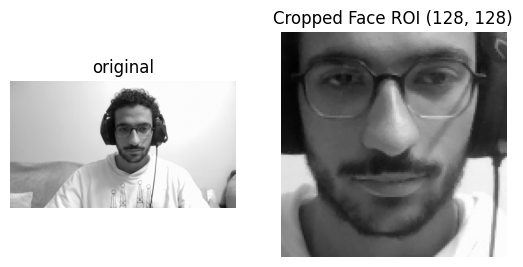

In [17]:
sample_path = "../fer2013/versions/1_preprocessed/train/angry/Training_11247006.jpg"
test_image_path = r"C:\Users\alira\Pictures\Camera Roll\WIN_20260319_12_54_05_Pro.jpg"

# Try processing the face
extracted_face = extract_face_roi(test_image_path, target_size= (128,128))
original = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)

if extracted_face is not None:
    # Visualize the output
    
    plt.Figure(figsize= (8,5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap= 'gray')
    plt.title('original')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(extracted_face, cmap='gray')
    plt.title(f"Cropped Face ROI {extracted_face.shape}")
    plt.axis('off')
    
    plt.show()

# Feature Extraction
Now that we have done with detecting the face region we neee to extract the features of the face.</br>
for this we have 3 methods used together:
1. Primary (shape): Histogram of Oriented Gradients (HOG)
2. Secondary (texture): Local Binary Patterns (LBP)
3. Tertiary (Edges): Use Canny Edge Detection

then we will combine them

## HOG
**The Goal:** Capture the structural outline of the facial features (e.g., the wide curve of a happy smile, or the downward pull of a sad mouth) while ignoring changes in lighting

In [ ]:
from skimage.feature import hog

def extract_hog_features(img, pixels_per_cell = (8, 8), cells_per_block = (2, 2), orientations = 9):
    """
    Extract HOG features from a face image.
    
    Args:
        img: 2D grayscale image (e.g., 48x48)
        pixels_per_cell: cell size for gradient histogram
        cells_per_block: block size for normalisation
        orientations: number of orientation bins
    
    Returns:
        1D numpy array of HOG features
    """
    # Visualize HOG (optional for report/debugging)
    _, hog_image = hog(img, orientations=orientations, pixels_per_cell=pixels_per_cell,
                       cells_per_block=cells_per_block, visualize=True)
    
    plt.Figure(figsize= (8, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap= 'gray')
    plt.title('original')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(hog_image, cmap= 'gray')
    plt.title('HOG output')
    plt.axis('off')
    plt.show()
    
    features = hog(
        img, orientations = orientations,
        pixels_per_cell= pixels_per_cell,
        cells_per_block = cells_per_block,
        block_norm='L2-Hys', transform_sqrt=True,
        feature_vector=True
    )
    
    return features

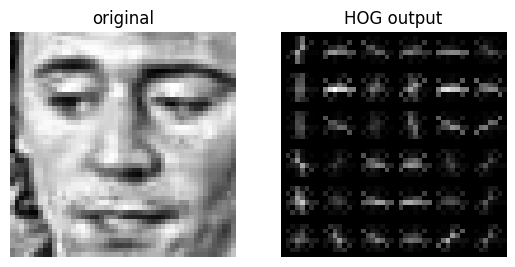

In [14]:
extracted_sample = extract_face_roi(sample_path)
features = extract_hog_features(extracted_sample)

# sample_img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
# features = extract_hog_features(sample_img)

## LBP

In [7]:
from skimage.feature import local_binary_pattern as lbp

def extract_lpb_features():
    pass



## Canny Edge Detection

In [8]:
def extract_edge_features():
    pass

## Combine

In [9]:
def combine_features():
    pass
